## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [4]:
from google.colab import files
uploaded = files.upload()
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

Saving marketing_campaign.csv to marketing_campaign.csv


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [5]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [6]:
# Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
income_mean = customer_data['Income'].mean()
customer_data['Income'] = customer_data['Income'].fillna(income_mean)
print("Số lượng giá trị khuyết còn lại trong cột Income:", customer_data['Income'].isnull().sum())
customer_data.info()

Số lượng giá trị khuyết còn lại trong cột Income: 0
<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2240 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   i

#### A3. Feature engineering

In [ ]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']
customer_data[['Year_Birth', 'Age']].head()

,Year_Birth,Age
ID,,
5524,1957,65
2174,1954,68
4141,1965,57
6182,1984,38
5324,1981,41


- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [9]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
import datetime
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], dayfirst=True)
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days
customer_data[['Dt_Customer', 'Enroll_days']].head()

,Dt_Customer,Enroll_days
ID,,
5524,2012-09-04,5145
2174,2014-03-08,4595
4141,2013-08-21,4794
6182,2014-02-10,4621
5324,2014-01-19,4643


- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [10]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Marital_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status_Num'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status_Num'] + customer_data['Kidhome'] + customer_data['Teenhome']
customer_data[['Marital_Status', 'Kidhome', 'Teenhome', 'Fam_Size']].head()

,Marital_Status,Kidhome,Teenhome,Fam_Size
ID,,,,
5524,Single,0,0,1
2174,Single,1,1,3
4141,Together,0,0,2
6182,Together,1,0,3
5324,Married,1,0,3


- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [11]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (
    customer_data['AcceptedCmp1'] +
    customer_data['AcceptedCmp2'] +
    customer_data['AcceptedCmp3'] +
    customer_data['AcceptedCmp4'] +
    customer_data['AcceptedCmp5']
)
customer_data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Num_Accepted']].head()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Num_Accepted
ID,,,,,,
5524,0,0,0,0,0,0
2174,0,0,0,0,0,0
4141,0,0,0,0,0,0
6182,0,0,0,0,0,0
5324,0,0,0,0,0,0


In [12]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (
    customer_data['MntWines'] +
    customer_data['MntFruits'] +
    customer_data['MntMeatProducts'] +
    customer_data['MntFishProducts'] +
    customer_data['MntSweetProducts'] +
    customer_data['MntGoldProds']
)
customer_data[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'MntTotal']].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,MntTotal
ID,,,,,,,
5524,635,88,546,172,88,88,1617
2174,11,1,6,2,1,6,27
4141,426,49,127,111,21,42,776
6182,11,4,20,10,3,5,53
5324,173,43,118,46,27,15,422


#### A4. Phân tích EDA

In [ ]:
customer_data.describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

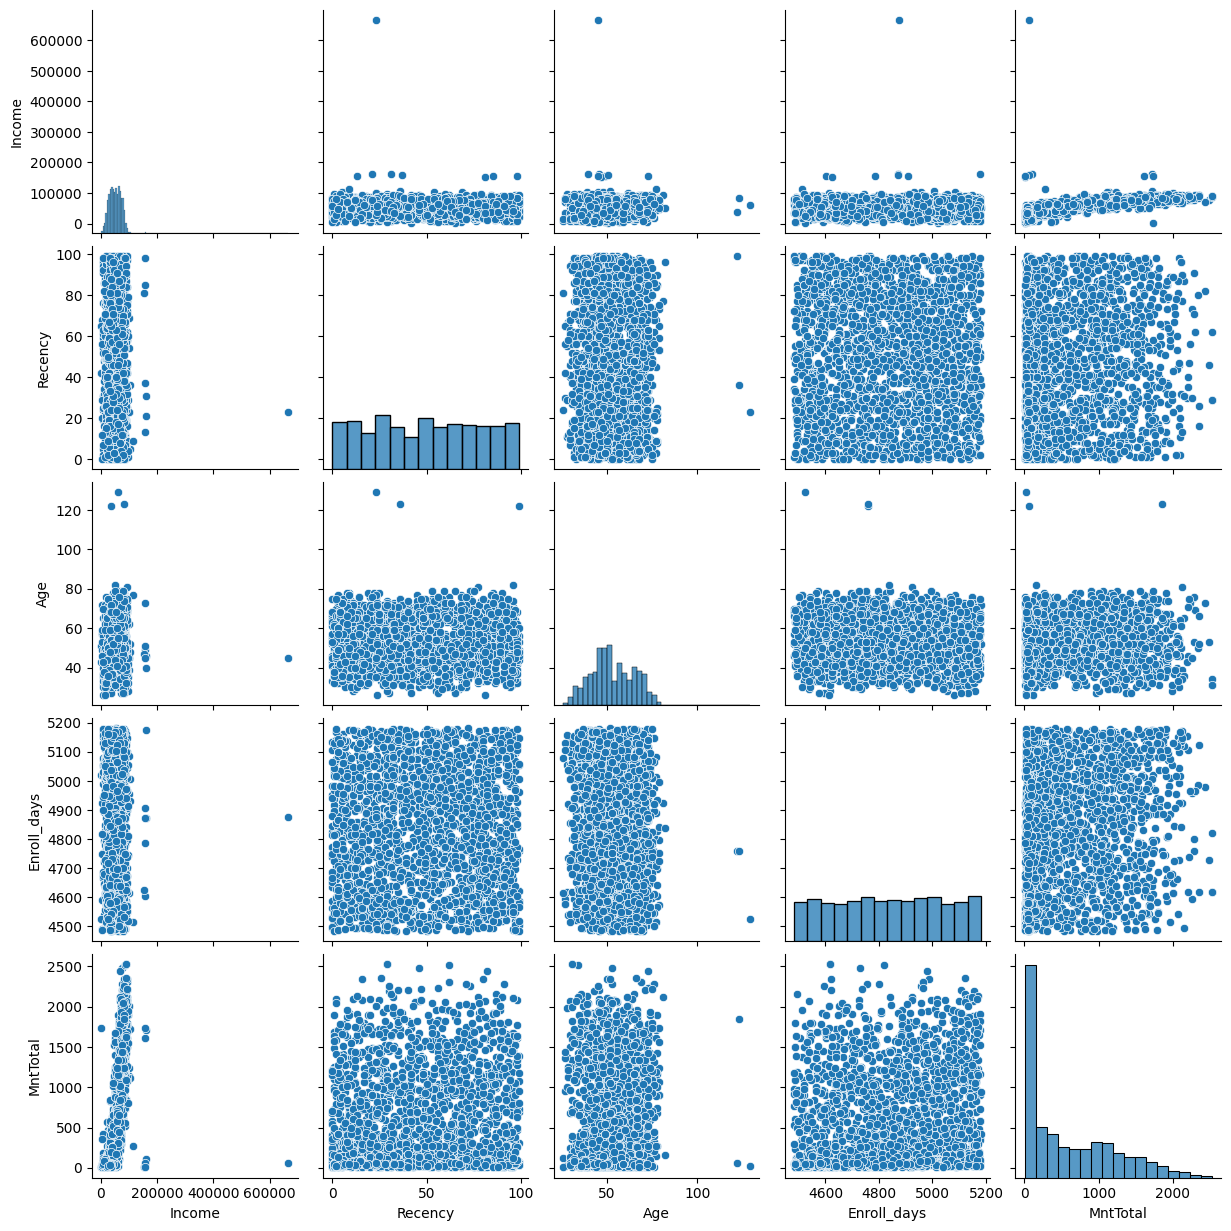

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# Vẽ pair plot sử dụng seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(customer_data[plot_cols])
plt.show()

In [15]:
# Loại bỏ các outlier dựa trên phân tích trực quan
customer_data = customer_data[customer_data['Age'] < 100]
customer_data = customer_data[customer_data['Income'] < 600000]
print("Kích thước tập dữ liệu sau khi lọc nhiễu:", customer_data.shape)

Kích thước tập dữ liệu sau khi lọc nhiễu: (2236, 34)


In [ ]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [18]:
import copy

# Đảm bảo df được khởi tạo đúng cách từ customer_data
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True, errors='ignore')

# Kiểm tra lại các cột hiện có trong df
print("Các cột hiện tại trong df:")
df.info()
print("\n=> Nhận xét: Do các đặc trưng phân loại đã được drop hoặc chuyển đổi sang dạng số ở các bước trước, df hiện tại chỉ chứa các cột số. Chúng ta không cần mã hóa thêm đặc trưng kiểu loại.")

Các cột hiện tại trong df:
<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 5524 to 9405
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2236 non-null   float64
 1   Recency              2236 non-null   int64  
 2   NumDealsPurchases    2236 non-null   int64  
 3   NumWebPurchases      2236 non-null   int64  
 4   NumCatalogPurchases  2236 non-null   int64  
 5   NumStorePurchases    2236 non-null   int64  
 6   NumWebVisitsMonth    2236 non-null   int64  
 7   Age                  2236 non-null   int64  
 8   Enroll_days          2236 non-null   int64  
 9   Marital_Status_Num   2236 non-null   int64  
 10  Fam_Size             2236 non-null   int64  
 11  MntTotal             2236 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 227.1 KB

=> Nhận xét: Do các đặc trưng phân loại đã được drop hoặc chuyển đổi sang dạng số ở các bước trước, df hiện tại ch

**Chuẩn hoá các thuộc tính kiểu số**

In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Khởi tạo bộ chuẩn hóa StandardScaler
scaler = StandardScaler()

# Chuẩn hóa tất cả các thuộc tính số trong df
scaled_features = scaler.fit_transform(df)

# Tạo lại DataFrame với các đặc trưng đã chuẩn hóa
df_scaled = pd.DataFrame(scaled_features, columns=df.columns, index=df.index)

# Gán ngược lại df để đồng bộ với các bước tiếp theo trong notebook
df = df_scaled
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Marital_Status_Num,Fam_Size,MntTotal
ID,,,,,,,,,,,,
5524,0.288513,0.306856,0.348738,1.407639,2.509801,-0.552429,0.692865,1.016868,1.529793,-1.347635,-1.758810,1.680176
2174,-0.262438,-0.383971,-0.168700,-1.110921,-0.568970,-1.167738,-0.131421,1.273264,-1.191143,-1.347635,0.445618,-0.962202
4141,0.917992,-0.798467,-0.686137,1.407639,-0.226884,1.293496,-0.543564,0.333146,-0.206659,0.742041,-0.656596,0.282541
6182,-1.182621,-0.798467,-0.168700,-0.751127,-0.911056,-0.552429,0.280722,-1.290693,-1.062517,0.742041,0.445618,-0.918994
5324,0.295754,1.550344,1.383614,0.328256,0.115201,0.062879,-0.131421,-1.034298,-0.953679,0.742041,0.445618,-0.305762


In [ ]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

#### A6. Phân cụm KMeans

In [ ]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

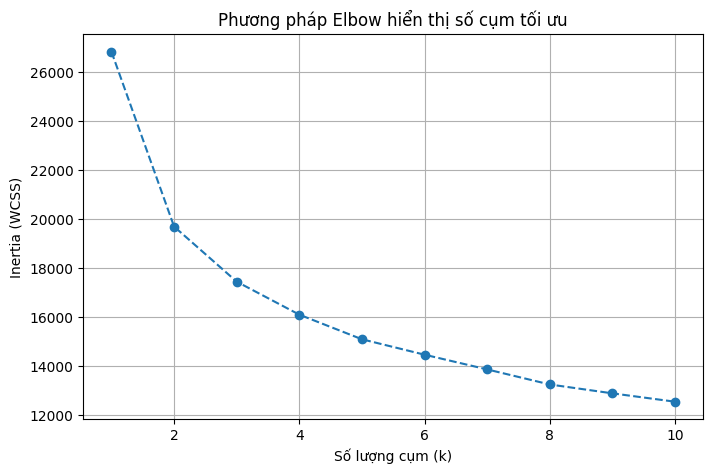

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Tính toán Inertia (WCSS) cho số lượng cụm từ 1 đến 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Phương pháp Elbow hiển thị số cụm tối ưu')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

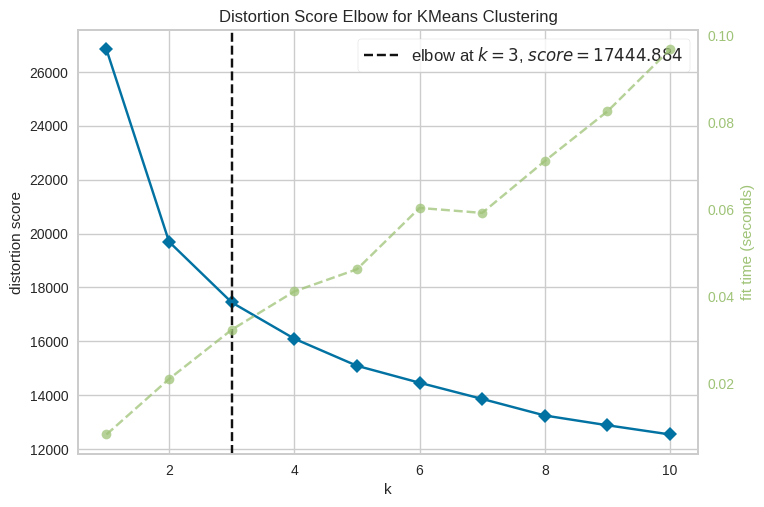

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [23]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Sử dụng KElbowVisualizer để tìm k tối ưu
model = KMeans(n_init=10, random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11))

visualizer.fit(df)        # Huấn luyện bộ trực quan hóa với dữ liệu
visualizer.show()        # Hiển thị biểu đồ

**Phân cụm từ kết quả của phương pháp Elbow**

In [24]:
# Tiến hành phân cụm với k = 4
kmean = KMeans(n_clusters=4, n_init=10, random_state=42)
kmean.fit(df)

# Lưu lại nhãn phân cụm
kmean_labels = kmean.labels_
print("Đã phân cụm thành công với k=4. Số lượng mẫu trong mỗi cụm:")
print(pd.Series(kmean_labels).value_counts())

Đã phân cụm thành công với k=4. Số lượng mẫu trong mỗi cụm:
3    673
2    663
0    490
1    410
Name: count, dtype: int64


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [ ]:
from sklearn.decomposition import PCA

In [25]:
from sklearn.decomposition import PCA

# Khởi tạo mô hình PCA giảm xuống còn 2 chiều
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(df)

print("Kích thước dữ liệu sau khi giảm chiều bằng PCA:", pca_transformed.shape)

Kích thước dữ liệu sau khi giảm chiều bằng PCA: (2236, 2)


**Trực quan hoá kết quả phân cụm**

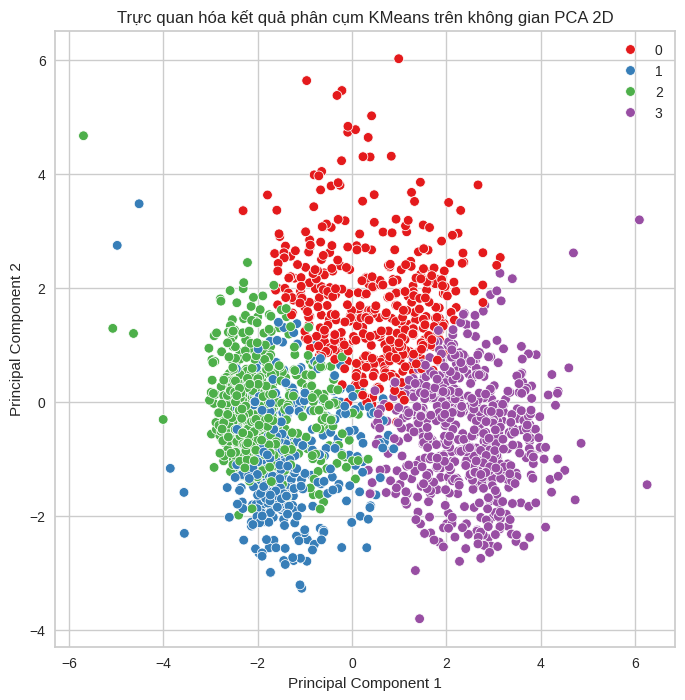

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.title('Trực quan hóa kết quả phân cụm KMeans trên không gian PCA 2D')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

# Gọi hàm trực quan hóa kết quả
visualize_cluster_result(pca_transformed, kmean_labels)

#### Phân tích kết quả phân cụm (KMeans)

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

In [ ]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]

    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count,
            explode=[0.05]*len(ulabels),
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

In [ ]:
# visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

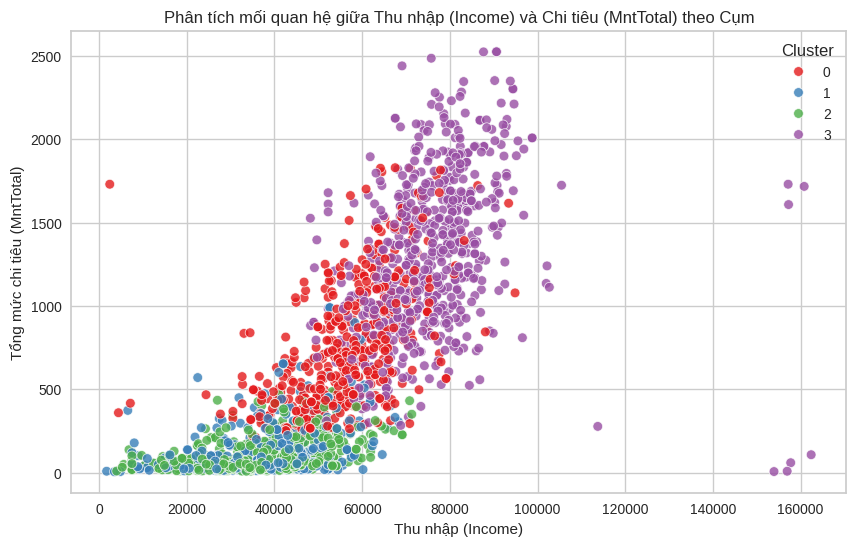

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo kmean_df đã được định nghĩa đúng cách
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1', alpha=0.8)
plt.title('Phân tích mối quan hệ giữa Thu nhập (Income) và Chi tiêu (MntTotal) theo Cụm')
plt.xlabel('Thu nhập (Income)')
plt.ylabel('Tổng mức chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

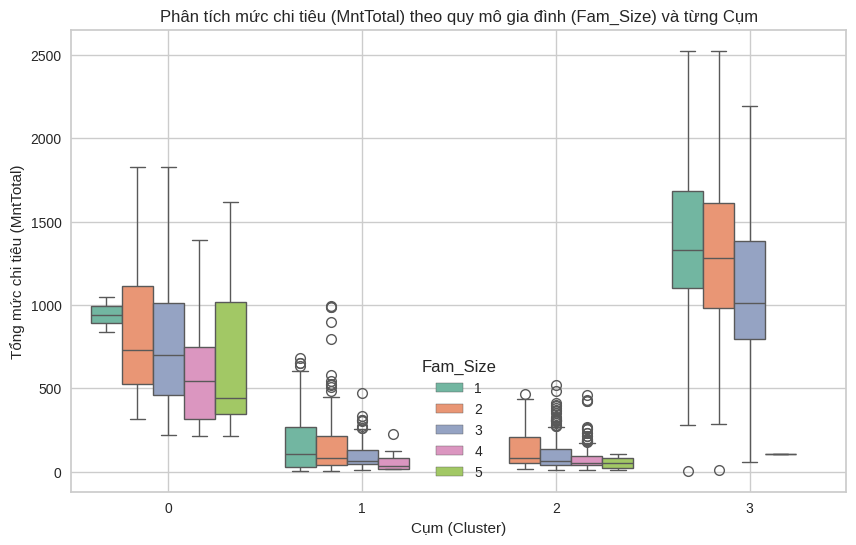

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo kmean_df đã được định nghĩa đúng cách
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean_labels

plt.figure(figsize=(10, 6))
sns.boxplot(data=kmean_df, x='Cluster', y='MntTotal', hue='Fam_Size', palette='Set2')
plt.title('Phân tích mức chi tiêu (MntTotal) theo quy mô gia đình (Fam_Size) và từng Cụm')
plt.xlabel('Cụm (Cluster)')
plt.ylabel('Tổng mức chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

**Phân tích danh mục mua hàng**

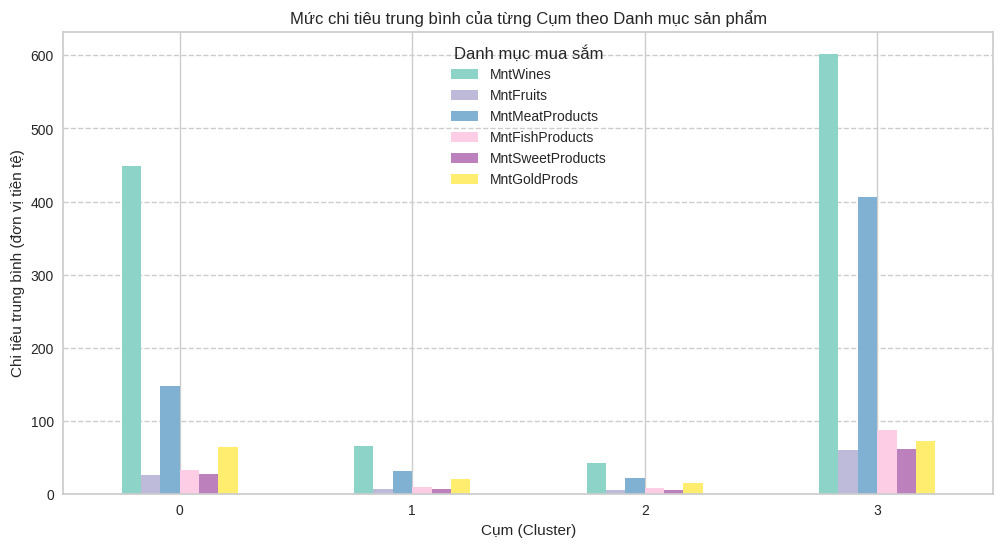

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các danh mục mua sắm
purchase_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Tính chi tiêu trung bình theo từng Cụm khách hàng
cluster_spending = kmean_df.groupby('Cluster')[purchase_cols].mean()

# Vẽ biểu đồ cột chồng nhóm thể hiện xu hướng tiêu dùng
cluster_spending.plot(kind='bar', figsize=(12, 6), colormap='Set3')
plt.title('Mức chi tiêu trung bình của từng Cụm theo Danh mục sản phẩm')
plt.xlabel('Cụm (Cluster)')
plt.ylabel('Chi tiêu trung bình (đơn vị tiền tệ)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.legend(title='Danh mục mua sắm')
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [ ]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))

    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)

    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')

    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')

    plt.grid(True)

In [ ]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [32]:
from sklearn.decomposition import PCA

# Khởi tạo PCA để giảm dữ liệu xuống còn 4 chiều
pca_4d = PCA(n_components=4, random_state=42)
pca_transformed_4d = pca_4d.fit_transform(df)

print("Kích thước của dữ liệu sau khi giảm xuống PCA 4 chiều:", pca_transformed_4d.shape)
print("Tỷ lệ phương sai tích lũy được giải thích (Cumulative Explained Variance):", sum(pca_4d.explained_variance_ratio_))

Kích thước của dữ liệu sau khi giảm xuống PCA 4 chiều: (2236, 4)
Tỷ lệ phương sai tích lũy được giải thích (Cumulative Explained Variance): 0.6874558890147618


In [ ]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [33]:
from sklearn.cluster import KMeans
import pandas as pd

# Khởi tạo và huấn luyện KMeans trên không gian giảm chiều PCA 4D
kmean_pca = KMeans(n_clusters=4, n_init=10, random_state=42)
kmean_pca.fit(pca_transformed_4d)

# Gán nhãn phân cụm vào DataFrame kmean_pca_df
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean_pca.labels_
print("Phân phối số lượng mẫu của các cụm sau khi dùng PCA 4D:")
print(kmean_pca_df['Cluster'].value_counts())
kmean_pca_df.head()

Phân phối số lượng mẫu của các cụm sau khi dùng PCA 4D:
Cluster
0    668
1    665
2    494
3    409
Name: count, dtype: int64


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Marital_Status_Num,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5145,1,1,0,1617,1
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,1,3,0,27,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,2,2,0,776,1
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,2,3,0,53,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,2,3,0,422,2


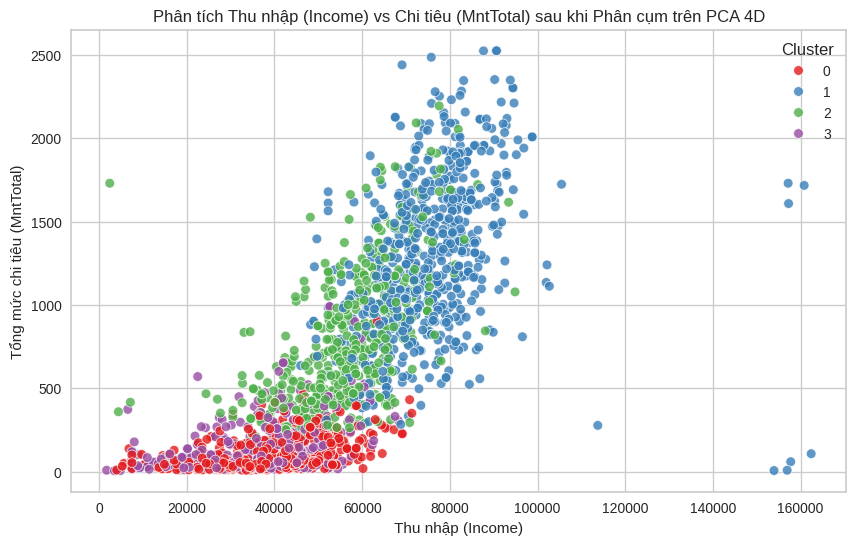

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ Scatter thể hiện Income và MntTotal theo cụm mới từ PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1', alpha=0.8)
plt.title('Phân tích Thu nhập (Income) vs Chi tiêu (MntTotal) sau khi Phân cụm trên PCA 4D')
plt.xlabel('Thu nhập (Income)')
plt.ylabel('Tổng mức chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [ ]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

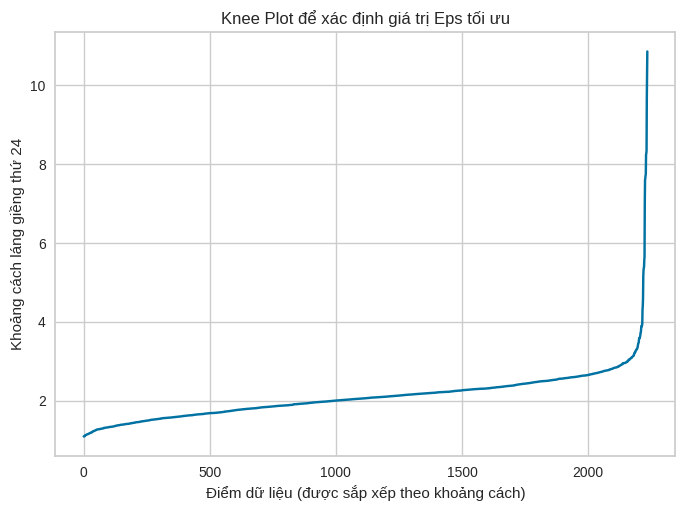

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors

def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # Sắp xếp khoảng cách
    distances = np.sort(distances, axis=0)
    distances = distances[:, -1] # Lấy khoảng cách đến láng giềng xa nhất thứ k
    plt.plot(distances)
    return distances

# Sử dụng số lượng láng giềng phù hợp (2 * số chiều dữ liệu = 24)
distances = knee_plot(n_neighs=24, data=df)

plt.title('Knee Plot để xác định giá trị Eps tối ưu')
plt.xlabel('Điểm dữ liệu (được sắp xếp theo khoảng cách)')
plt.ylabel('Khoảng cách láng giềng thứ 24')
plt.grid(True)
plt.show()

In [39]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)

    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [41]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi

In [40]:
import pandas as pd

In [43]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('taxi_data.csv')
df.head()

Saving taxi_data.csv to taxi_data.csv


,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [44]:
import folium, re

In [48]:
# Loại bỏ các dòng chứa giá trị khuyết (NaN) trong tọa độ trước khi vẽ bản đồ
df = df.dropna(subset=['LAT', 'LON'])

X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [49]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

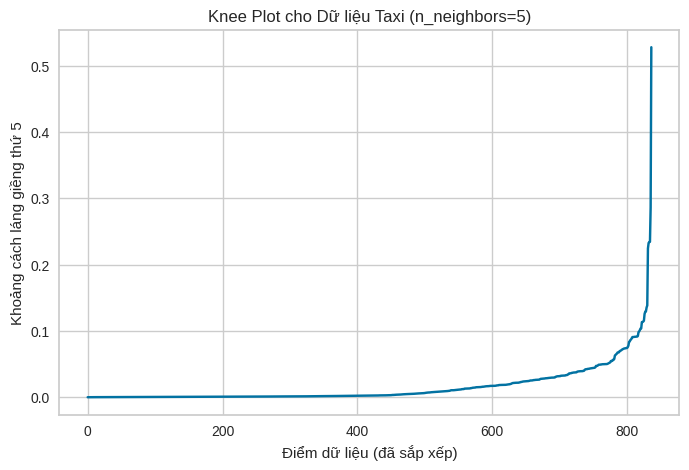

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Tìm khoảng cách tới láng giềng gần thứ 5 (Min_samples = 5)
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

# Sắp xếp và vẽ Knee Plot
distances = np.sort(distances, axis=0)
distances = distances[:, -1]

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('Knee Plot cho Dữ liệu Taxi (n_neighbors=5)')
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách láng giềng thứ 5')
plt.grid(True)
plt.show()

In [50]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink',
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [56]:
from sklearn.cluster import DBSCAN
import folium

# Dựa vào Knee plot, ta ước lượng giá trị eps khoảng 0.03
db = DBSCAN(eps=0.03, min_samples=5)
db.fit(X)

# Gán kết quả phân cụm vào DataFrame
df['Cluster'] = db.labels_

# Gán màu sắc cho từng cụm (các điểm nhiễu có nhãn -1 sẽ có màu đen)
df['Color'] = df['Cluster'].apply(lambda val: 'black' if val == -1 else colors[val % len(colors)])

# Hiển thị số lượng điểm trong từng cụm
print("Số lượng trạm taxi trong mỗi cụm (Cụm -1 là điểm nhiễu/outlier):")
print(df['Cluster'].value_counts())

# Định nghĩa hàm tạo bản đồ an toàn ngay tại đây và hiển thị
def create_map_safe(cluster_column, colors_column, title_text):
    m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=8.5)
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    title_html = f'''<h3 align="center" style="font-size:20px"><b>{title_text}</b></h3>'''
    m.get_root().html.add_child(folium.Element(title_html))
    return m

create_map_safe(cluster_column='Cluster', colors_column='Color', title_text='Bản đồ phân cụm vị trí trạm Taxi bằng DBSCAN')

Số lượng trạm taxi trong mỗi cụm (Cụm -1 là điểm nhiễu/outlier):
Cluster
-1     122
 4     102
 11     77
 1      55
 2      46
 12     36
 0      31
 5      26
 3      24
 7      23
 19     22
 31     18
 30     14
 37     14
 24     13
 36     12
 35     12
 16     11
 25     11
 14     10
 15     10
 32     10
 21      9
 10      9
 8       8
 6       8
 38      8
 33      8
 9       8
 26      8
 17      8
 20      8
 34      7
 23      6
 39      6
 27      6
 22      6
 13      5
 18      5
 28      5
 29      5
 40      5
Name: count, dtype: int64


In [55]:
def create_map(cluster_column, colors_column, title):
    # Sử dụng 'OpenStreetMap' để tránh lỗi bản quyền tile Stamen Toner
    m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=8.5)
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m